Unemployment Analysis with Python

## Project Objective
Analyze unemployment-rate data using Python to:
- clean and prepare the dataset
- explore unemployment patterns
- visualize unemployment trends
- investigate the impact of COVID-19
- identify regional, rural/urban, and seasonal patterns
- generate insights that can support economic and social policy discussions


In [4]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

The notebook first tries to load the uploaded CSV from the same folder as the notebook.  
If that path is not available, change `DATA_PATH` to the location of your CSV file.


In [5]:
# 2. Load dataset
DATA_PATH = "66f4d05d-0d50-4828-b937-c311c3244dad"

# If your notebook is in another folder, replace DATA_PATH with the full path.
df = pd.read_csv(r"C:\Users\gchar\Downloads\Unemployment in India.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 3. Understand the Dataset


In [6]:
# 3. Basic inspection
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (768, 7)

Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

Missing values:


,Missing Values
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28



Duplicate rows: 27


## 4. Data Cleaning

Column names contain extra spaces in the original file. The cleaning steps:
1. remove unnecessary spaces from column names
2. remove duplicate rows
3. convert the date column to datetime
4. convert numerical columns to numeric values
5. remove rows where the unemployment rate is missing
6. create useful time variables


In [7]:
# 4. Clean the data
df.columns = df.columns.str.strip()

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Convert date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Convert numerical columns
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows without a usable date or unemployment rate
df = df.dropna(subset=["Date", "Estimated Unemployment Rate (%)"]).copy()

# Standardize text columns
for col in ["Region", "Frequency", "Area"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name().str[:3]

# Sort for time-series analysis
df = df.sort_values(["Region", "Area", "Date"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (740, 10)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,Jun
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,Jul
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,Aug
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,Sep


## 5. Descriptive Statistics


In [8]:
# 5. Summary statistics
display(df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].describe().round(2))


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


## 6. Overall Unemployment Trend

This chart shows how the unemployment rate changes over time. The vertical dashed line marks the start of the analytical COVID-19 period (March 2020).


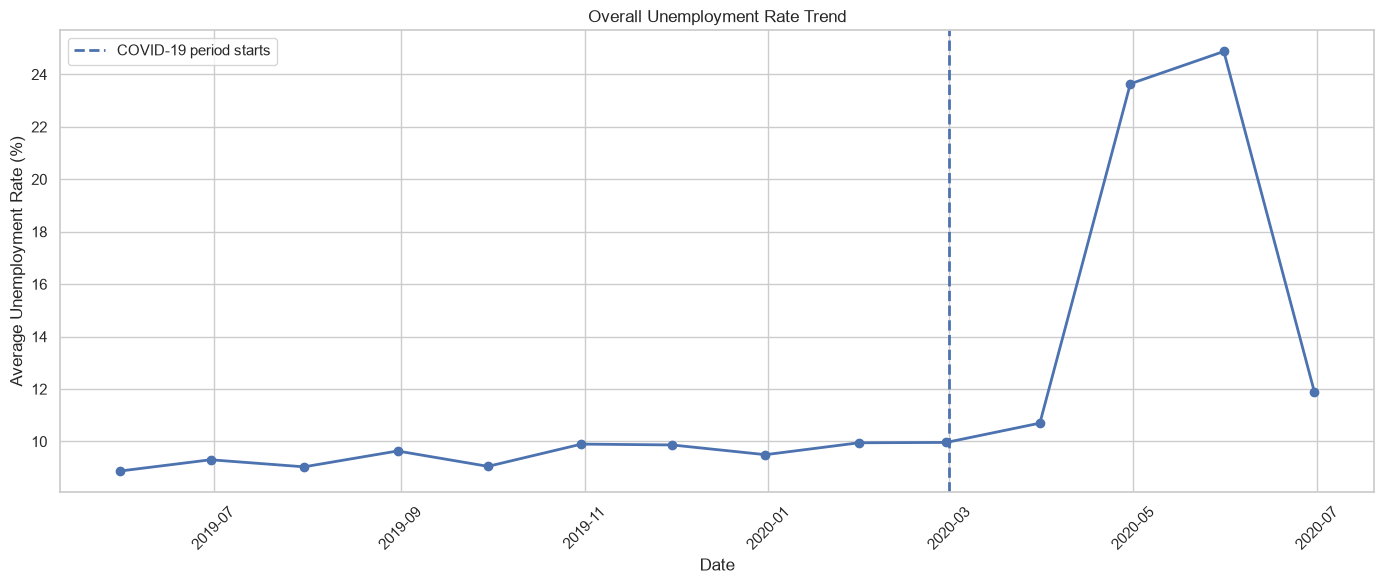

In [9]:
# 6. Overall trend
monthly_overall = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_overall["Date"],
    monthly_overall["Estimated Unemployment Rate (%)"],
    marker="o",
    linewidth=2
)
plt.axvline(pd.Timestamp("2020-03-01"), linestyle="--", linewidth=2, label="COVID-19 period starts")
plt.title("Overall Unemployment Rate Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. COVID-19 Impact Analysis

For a simple comparison, the notebook divides observations into:
- **Pre-COVID:** before March 2020
- **COVID period:** March 2020 onward

It calculates average unemployment and the percentage-point change.


In [10]:
# 7. COVID period comparison
df["COVID_Period"] = np.where(
    df["Date"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "COVID Period"
)

covid_summary = (
    df.groupby("COVID_Period")["Estimated Unemployment Rate (%)"]
      .agg(["mean", "median", "min", "max", "count"])
      .round(2)
)

display(covid_summary)

pre = df.loc[df["COVID_Period"] == "Pre-COVID", "Estimated Unemployment Rate (%)"].mean()
covid = df.loc[df["COVID_Period"] == "COVID Period", "Estimated Unemployment Rate (%)"].mean()

print(f"Average unemployment rate before COVID-19: {pre:.2f}%")
print(f"Average unemployment rate during COVID period: {covid:.2f}%")
print(f"Change: {covid - pre:+.2f} percentage points")


,mean,median,min,max,count
COVID_Period,,,,,
COVID Period,17.77,14.52,0.0,76.74,204
Pre-COVID,9.51,7.12,0.0,34.69,536


Average unemployment rate before COVID-19: 9.51%
Average unemployment rate during COVID period: 17.77%
Change: +8.26 percentage points


## 8. COVID-19 Impact by Region

The following table compares each region's average unemployment rate before and during the COVID period.


In [11]:
# 8. Regional COVID comparison
regional_covid = (
    df.groupby(["Region", "COVID_Period"])["Estimated Unemployment Rate (%)"]
      .mean()
      .unstack()
)

for col in ["Pre-COVID", "COVID Period"]:
    if col not in regional_covid.columns:
        regional_covid[col] = np.nan

regional_covid["Change (percentage points)"] = (
    regional_covid["COVID Period"] - regional_covid["Pre-COVID"]
)

regional_covid = regional_covid.sort_values(
    "Change (percentage points)", ascending=False
).round(2)

display(regional_covid)


COVID_Period,COVID Period,Pre-COVID,Change (percentage points)
Region,,,
Puducherry,38.96,1.59,37.36
Tamil Nadu,25.40,2.84,22.57
Jharkhand,36.35,14.28,22.07
Bihar,31.63,13.83,17.80
Karnataka,15.28,3.23,12.05
Haryana,34.65,22.94,11.72
Kerala,17.95,6.99,10.96
Telangana,15.44,4.66,10.79
Madhya Pradesh,14.07,4.74,9.33


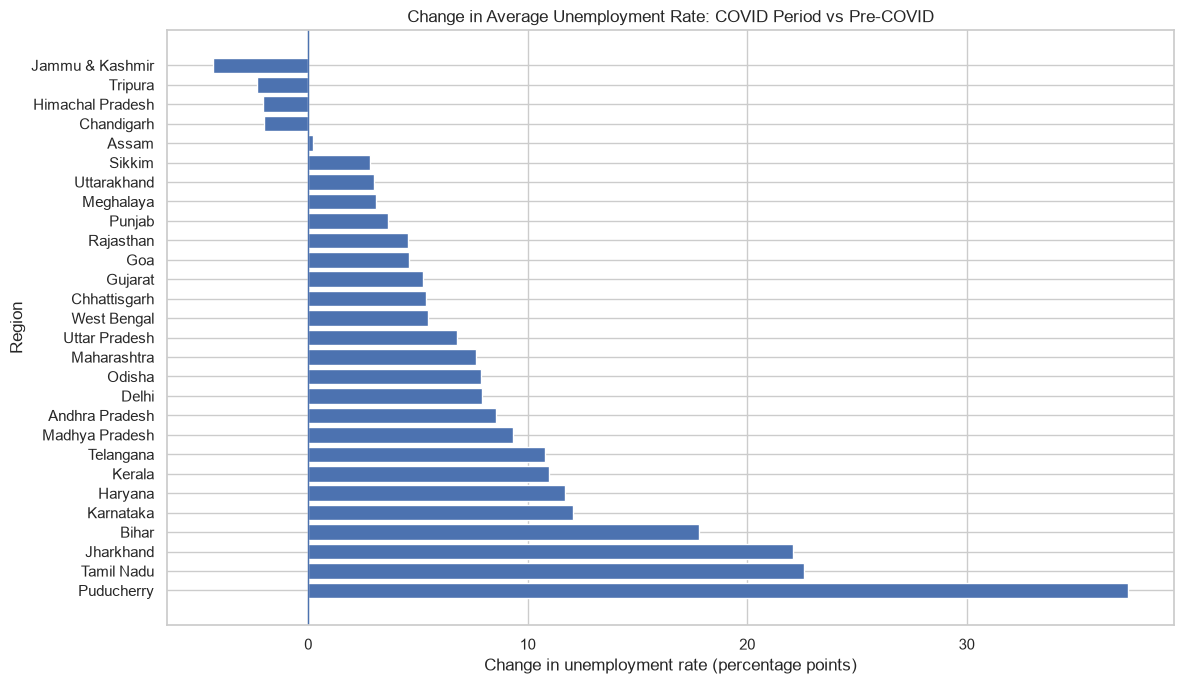

In [12]:
# 9. Visualize regional COVID impact
plot_df = regional_covid.reset_index()

plt.figure(figsize=(12, 7))
plt.barh(
    plot_df["Region"],
    plot_df["Change (percentage points)"]
)
plt.axvline(0, linewidth=1)
plt.title("Change in Average Unemployment Rate: COVID Period vs Pre-COVID")
plt.xlabel("Change in unemployment rate (percentage points)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


## 9. Rural vs Urban Analysis

If the dataset contains an `Area` column, compare unemployment rates for Rural and Urban areas.


COVID_Period,COVID Period,Pre-COVID
Area,,
Rural,16.18,8.09
Urban,19.28,10.84


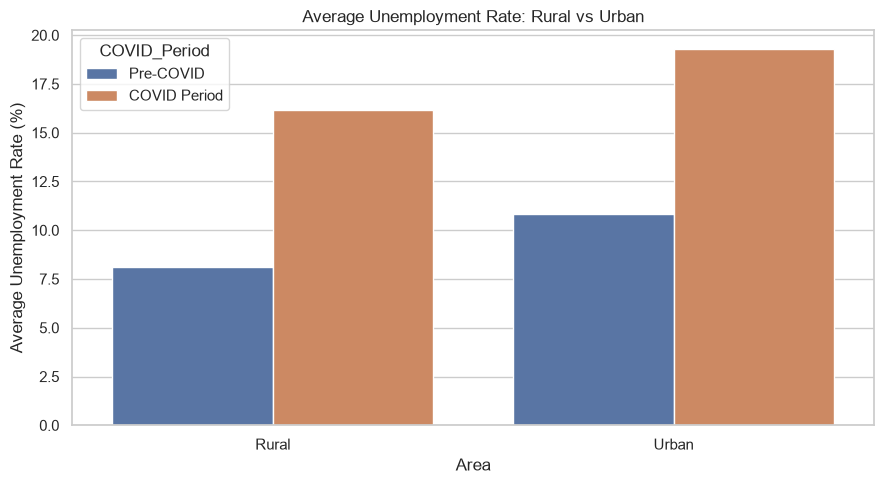

In [13]:
# 10. Rural vs Urban
if "Area" in df.columns:
    area_summary = (
        df.groupby(["Area", "COVID_Period"])["Estimated Unemployment Rate (%)"]
          .mean()
          .unstack()
          .round(2)
    )
    display(area_summary)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=df,
        x="Area",
        y="Estimated Unemployment Rate (%)",
        hue="COVID_Period",
        estimator="mean",
        errorbar=None
    )
    plt.title("Average Unemployment Rate: Rural vs Urban")
    plt.xlabel("Area")
    plt.ylabel("Average Unemployment Rate (%)")
    plt.tight_layout()
    plt.show()
else:
    print("Area column not found in this dataset.")


## 10. Regional Unemployment Trends

This line chart compares unemployment trends across regions.


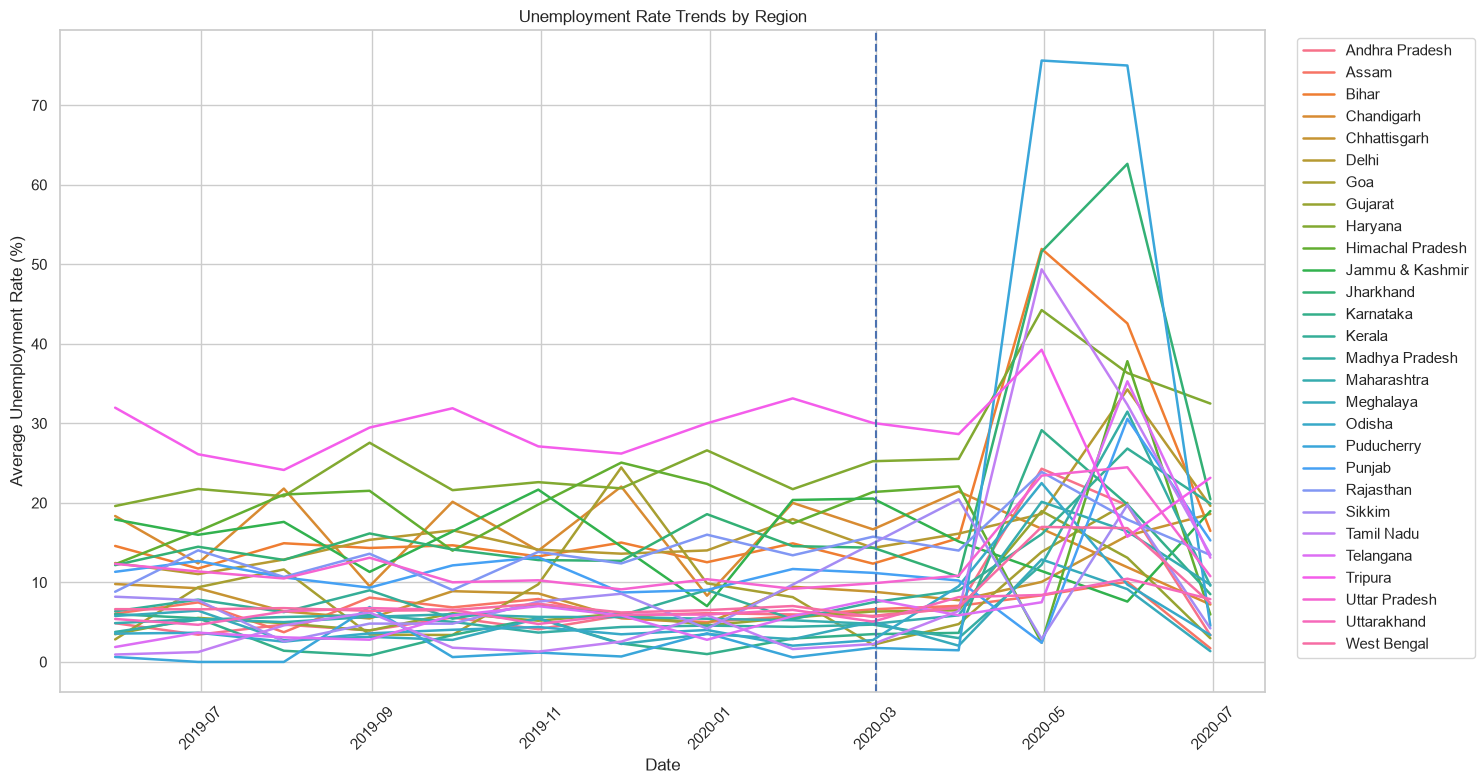

In [14]:
# 11. Region-wise trend
region_monthly = (
    df.groupby(["Date", "Region"])["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=region_monthly,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    linewidth=1.8
)
plt.axvline(pd.Timestamp("2020-03-01"), linestyle="--", linewidth=1.5)
plt.title("Unemployment Rate Trends by Region")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 11. Seasonal Pattern Analysis

Monthly averages are used to identify whether some months repeatedly show higher or lower unemployment.


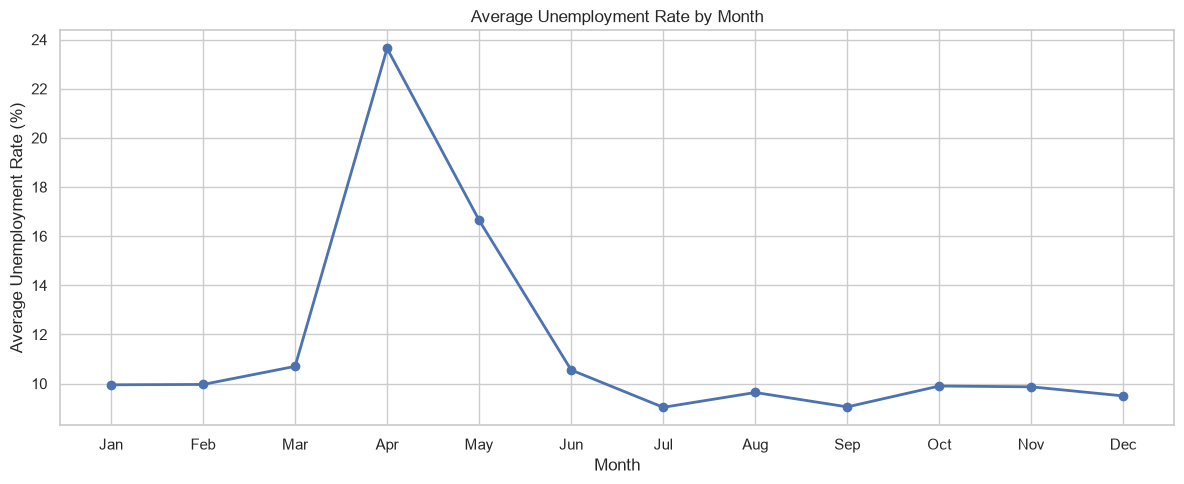

,Average Unemployment Rate (%)
Month,
Jan,9.95
Feb,9.96
Mar,10.70
Apr,23.64
May,16.65
Jun,10.55
Jul,9.03
Aug,9.64
Sep,9.05


In [15]:
# 12. Seasonal/monthly pattern
seasonal = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
      .reindex(range(1, 13))
)

month_labels = pd.date_range("2020-01-01", periods=12, freq="MS").strftime("%b")

plt.figure(figsize=(12, 5))
plt.plot(month_labels, seasonal.values, marker="o", linewidth=2)
plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

display(
    seasonal.rename(index=dict(enumerate(month_labels, start=1)))
          .to_frame("Average Unemployment Rate (%)")
          .round(2)
)


## 12. Highest and Lowest Unemployment Observations


In [16]:
# 13. Highest and lowest observations
cols = [
    "Region", "Date", "Area",
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]
available_cols = [c for c in cols if c in df.columns]

highest = df.nlargest(10, "Estimated Unemployment Rate (%)")[available_cols]
lowest = df.nsmallest(10, "Estimated Unemployment Rate (%)")[available_cols]

print("Top 10 highest unemployment observations:")
display(highest)

print("Top 10 lowest unemployment observations:")
display(lowest)


Top 10 highest unemployment observations:


,Region,Date,Area,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
497,Puducherry,2020-04-30,Urban,76.74,68122.0,35.54
498,Puducherry,2020-05-31,Urban,75.00,64538.0,31.25
485,Puducherry,2020-04-30,Rural,74.51,49420.0,46.79
305,Jharkhand,2020-05-31,Urban,70.17,830347.0,40.49
304,Jharkhand,2020-04-30,Urban,61.48,1054829.0,39.92
79,Bihar,2020-04-30,Urban,58.77,1400962.0,34.94
291,Jharkhand,2020-05-31,Rural,55.10,3315038.0,37.03
584,Tamil Nadu,2020-04-30,Rural,53.19,5086200.0,33.05
256,Himachal Pradesh,2020-05-31,Urban,50.00,134868.0,43.55
66,Bihar,2020-05-31,Rural,47.26,14050319.0,38.50


Top 10 lowest unemployment observations:


,Region,Date,Area,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
39,Assam,2020-06-30,Rural,0.0,7544937.0,34.38
105,Chhattisgarh,2020-04-30,Rural,0.0,6534321.0,39.43
159,Goa,2020-02-29,Rural,0.0,171672.0,36.11
474,Puducherry,2019-05-31,Rural,0.0,172474.0,43.08
475,Puducherry,2019-06-30,Rural,0.0,184527.0,45.95
476,Puducherry,2019-07-31,Rural,0.0,139227.0,34.56
478,Puducherry,2019-09-30,Rural,0.0,175718.0,43.34
480,Puducherry,2019-11-30,Rural,0.0,142787.0,35.00
487,Puducherry,2019-06-30,Urban,0.0,304369.0,37.73
488,Puducherry,2019-07-31,Urban,0.0,281117.0,34.77


## 13. Employment and Labour Participation

Unemployment should be interpreted together with employment and labour participation. These charts help show whether changes in unemployment happened alongside changes in the employed population and labour participation rate.


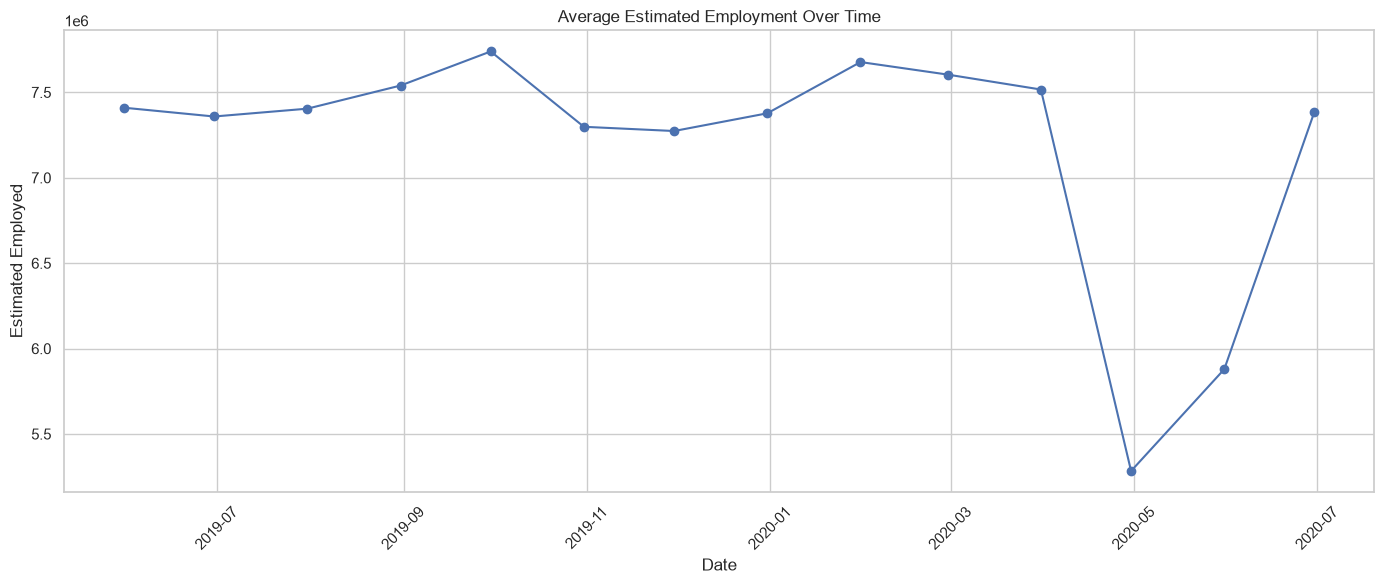

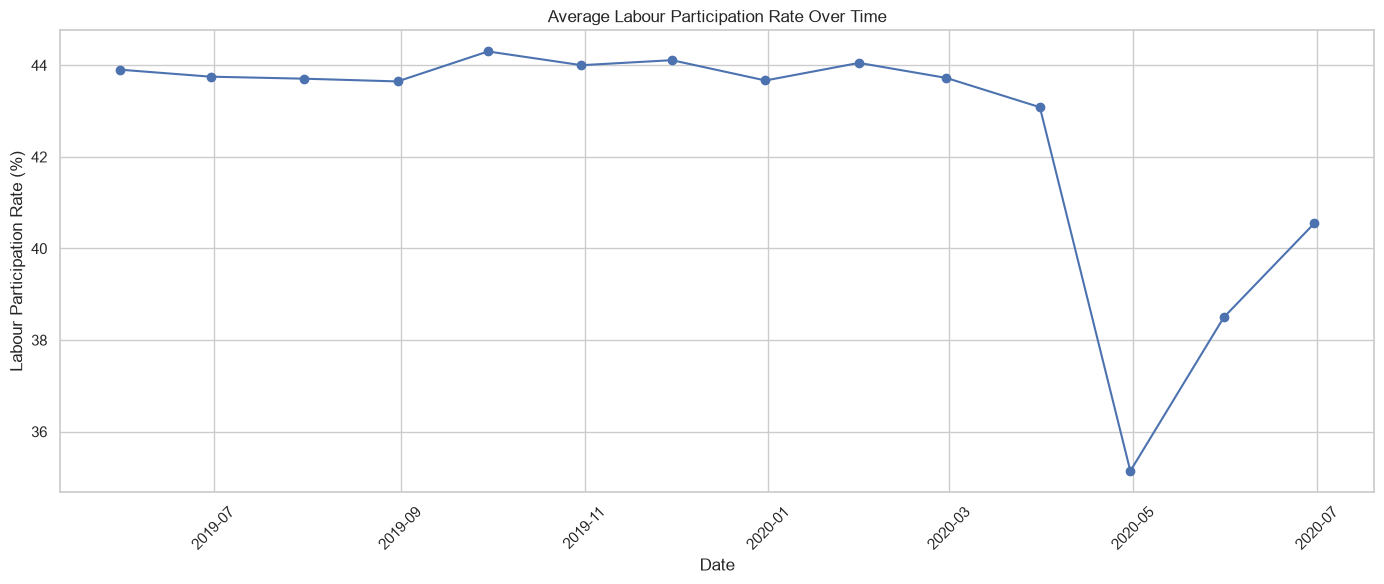

In [17]:
# 14. Employment and labour participation trends
overall_metrics = (
    df.groupby("Date")[
        ["Estimated Employed", "Estimated Labour Participation Rate (%)"]
    ].mean().reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    overall_metrics["Date"],
    overall_metrics["Estimated Employed"],
    marker="o"
)
plt.title("Average Estimated Employment Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(
    overall_metrics["Date"],
    overall_metrics["Estimated Labour Participation Rate (%)"],
    marker="o"
)
plt.title("Average Labour Participation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Correlation Analysis

Correlation can help identify relationships between unemployment, employment, and labour participation. Correlation does **not** prove causation.


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.00,-0.22,0.00
Estimated Employed,-0.22,1.00,0.01
Estimated Labour Participation Rate (%),0.00,0.01,1.00


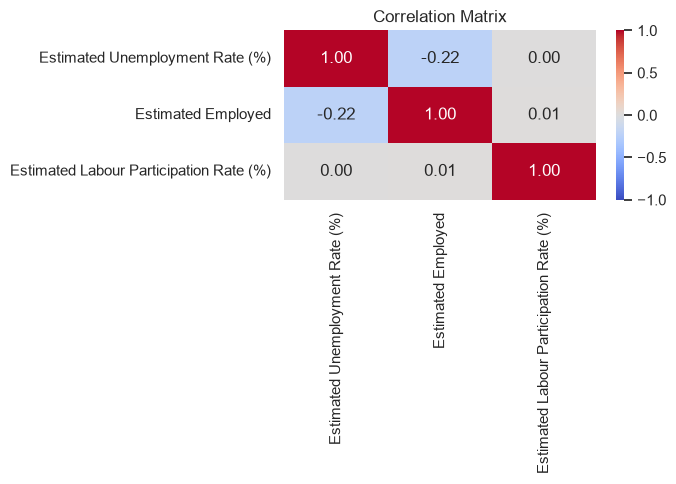

In [18]:
# 15. Correlation matrix
corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]
corr = df[corr_cols].corr().round(2)

display(corr)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 15. Key Insights

Run the next cell to automatically generate a concise set of findings from the uploaded dataset.


In [19]:
# 16. Automatically generated key insights
overall_mean = df["Estimated Unemployment Rate (%)"].mean()
overall_max_row = df.loc[df["Estimated Unemployment Rate (%)"].idxmax()]
overall_min_row = df.loc[df["Estimated Unemployment Rate (%)"].idxmin()]

print("KEY INSIGHTS")
print("=" * 60)
print(f"1. Overall average unemployment rate: {overall_mean:.2f}%")
print(
    f"2. Highest observed unemployment rate: "
    f"{overall_max_row['Estimated Unemployment Rate (%)']:.2f}% "
    f"in {overall_max_row['Region']} on {overall_max_row['Date'].date()}"
)
print(
    f"3. Lowest observed unemployment rate: "
    f"{overall_min_row['Estimated Unemployment Rate (%)']:.2f}% "
    f"in {overall_min_row['Region']} on {overall_min_row['Date'].date()}"
)

if not regional_covid.empty:
    top_region = regional_covid["Change (percentage points)"].idxmax()
    low_region = regional_covid["Change (percentage points)"].idxmin()
    print(
        f"4. Largest regional increase between the two periods: "
        f"{top_region} ({regional_covid.loc[top_region, 'Change (percentage points)']:+.2f} pp)"
    )
    print(
        f"5. Smallest regional change between the two periods: "
        f"{low_region} ({regional_covid.loc[low_region, 'Change (percentage points)']:+.2f} pp)"
    )

if "Area" in df.columns:
    area_means = df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()
    print("6. Average unemployment by area:")
    for area, value in area_means.sort_values(ascending=False).items():
        print(f"   - {area}: {value:.2f}%")

seasonal_high = seasonal.idxmax()
seasonal_low = seasonal.idxmin()
print(
    f"7. Highest average monthly unemployment occurs in month {seasonal_high} "
    f"({seasonal.loc[seasonal_high]:.2f}%)."
)
print(
    f"8. Lowest average monthly unemployment occurs in month {seasonal_low} "
    f"({seasonal.loc[seasonal_low]:.2f}%)."
)


KEY INSIGHTS
1. Overall average unemployment rate: 11.79%
2. Highest observed unemployment rate: 76.74% in Puducherry on 2020-04-30
3. Lowest observed unemployment rate: 0.00% in Assam on 2020-06-30
4. Largest regional increase between the two periods: Puducherry (+37.36 pp)
5. Smallest regional change between the two periods: Jammu & Kashmir (-4.33 pp)
6. Average unemployment by area:
   - Urban: 13.17%
   - Rural: 10.32%
7. Highest average monthly unemployment occurs in month 4 (23.64%).
8. Lowest average monthly unemployment occurs in month 7 (9.03%).


## 16. Policy-Relevant Interpretation

The analysis can support policy discussions in several ways:

- **Employment support:** Regions with larger unemployment increases may need targeted employment-generation and job-placement programs.
- **Rural and urban targeting:** If rural and urban unemployment differ substantially, policies can be designed around local labour-market conditions.
- **Crisis preparedness:** The COVID-period comparison shows why emergency employment and income-support mechanisms can be important during large economic shocks.
- **Skill development:** Persistent unemployment can motivate reskilling and upskilling programs aligned with local industry demand.
- **Seasonal planning:** If certain months consistently show higher unemployment, employment programs can be timed before or during those periods.
- **Data-driven monitoring:** Regular labour-market dashboards can help policymakers identify sudden changes earlier.

These are general policy implications based on observed patterns; the dataset alone cannot establish causal relationships.


## 17. Final Conclusion

This project used Python, Pandas, Matplotlib, and Seaborn to clean, explore, and visualize unemployment data. The analysis examined overall trends, COVID-19 period changes, regional differences, rural/urban differences, seasonal patterns, employment, and labour-force participation.

The most important takeaway is that unemployment should be studied across **time, geography, and population/area segments**, rather than relying on a single overall average. The resulting insights can help frame evidence-based discussions about employment generation, skills, crisis support, and regional development.
